# Detectron2 Beginner's Tutorial

<img src="https://dl.fbaipublicfiles.com/detectron2/Detectron2-Logo-Horz.png" width="500">

Welcome to detectron2! This is the official colab tutorial of detectron2. Here, we will go through some basics usage of detectron2, including the following:
* Run inference on images or videos, with an existing detectron2 model
* Train a detectron2 model on a new dataset

You can make a copy of this tutorial by "File -> Open in playground mode" and play with it yourself. __DO NOT__ request access to this tutorial.


# Environment

Dependencies live in the conda env `surf-detectron2` (see README).
Select the **Surf Detectron2** kernel before running.

In [1]:
# Environment check -- deps are installed in the conda env, not from the notebook.
import torch, torchvision

print("torch       ", torch.__version__)
print("torchvision ", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available :", torch.backends.mps.is_available())

torch        2.2.2
torchvision  0.17.2
CUDA available: False
MPS available : True


In [2]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
import matplotlib.pyplot as plt


def cv2_imshow(im, figsize=(12, 8)):
    """Local stand-in for google.colab.patches.cv2_imshow (BGR -> RGB)."""
    plt.figure(figsize=figsize)
    plt.imshow(im[:, :, ::-1])
    plt.axis("off")
    plt.show()

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.structures import Boxes

# Run a pre-trained detectron2 model

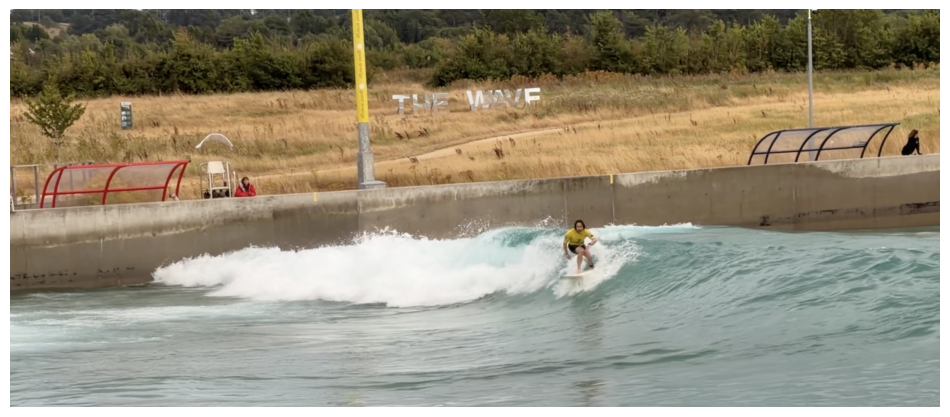

In [3]:
# Local image (was: Google Drive mount on Colab)
data_root = "Inaki_test2.jpg"  # wide shot; img.JPG is the original close-up

im = cv2.imread(data_root)
assert im is not None, f"could not read {data_root}"
cv2_imshow(im)

Then, we create a detectron2 config and a detectron2 `DefaultPredictor` to run inference on this image.

# Run Pose Estimation on Surf image:

[09/07 21:57:13 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x/137849621/model_final_a6e10b.pkl ...


/opt/miniconda3/envs/surf-detectron2/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


6 detection(s)


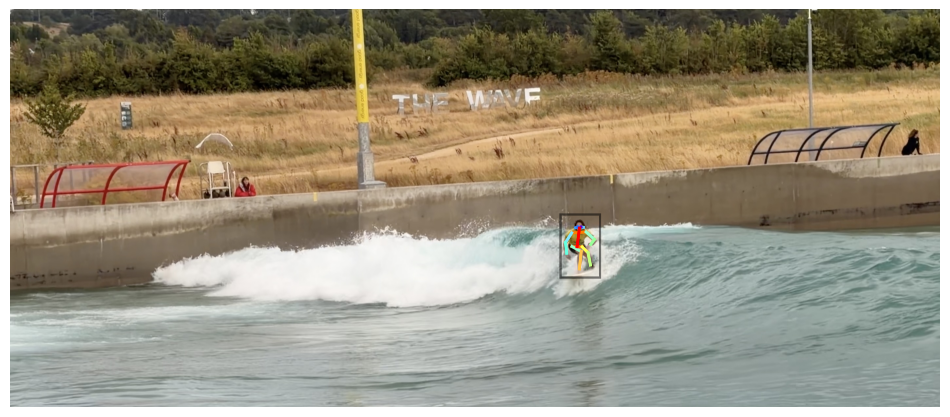

In [4]:
# Inference with a keypoint detection model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7  # set threshold for this model
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.DEVICE = "cpu"  # keypoint R-CNN uses ops MPS lacks; CPU is reliable

# The surfer is small in a wide shot. At the default 800/1333 detectron2
# resizes this 2834x1212 frame down to 1333x570, leaving the surfer ~51x76px
# -- too few pixels for the keypoint head, which then emits a scrambled pose.
# Inferring at full resolution takes it to ~106x169px and fixes it.
cfg.INPUT.MIN_SIZE_TEST = 1600   # default 800
cfg.INPUT.MAX_SIZE_TEST = 3000   # default 1333
predictor = DefaultPredictor(cfg)

# --- drawing options -------------------------------------------------------
# These are read at call time, so you can change one and re-run just the last
# few lines of this cell -- no need to redefine the functions below.
BOX_SCALE = 1.2       # 1.0 = tight box, 1.2 = 20% larger. NOT a percentage.
KEEP_LARGEST_ONLY = True   # keep only the biggest detection (drops spectators)
SHOW_LABELS = False        # draw the "person 100%" text


def keep_largest(instances):
    """Keep only the largest detection -- on a wide shot the model also finds
    spectators on the bank, and each one gets its own box and skeleton."""
    if len(instances) <= 1:
        return instances
    return instances[instances.pred_boxes.area().argmax().unsqueeze(0)]


def expand_boxes(instances, scale=None):
    """Grow each predicted box about its centre, clipped to the image.

    Cosmetic only -- detection and keypoints are untouched. A tight box sits
    right on the surfer's feet, so its lower edge cuts across the board.
    """
    scale = BOX_SCALE if scale is None else scale  # read now, not at def time
    b = instances.pred_boxes.tensor.clone()
    cx, cy = (b[:, 0] + b[:, 2]) / 2, (b[:, 1] + b[:, 3]) / 2
    w, h = (b[:, 2] - b[:, 0]) * scale, (b[:, 3] - b[:, 1]) * scale
    b = torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=1)

    H, W = instances.image_size
    b[:, 0::2] = b[:, 0::2].clamp(0, W)  # x1, x2
    b[:, 1::2] = b[:, 1::2].clamp(0, H)  # y1, y2

    instances.pred_boxes = Boxes(b)
    return instances


def strip_labels(instances):
    """Visualizer builds its caption from these two fields; drop them and it
    draws the box and skeleton with no text."""
    for field in ("scores", "pred_classes"):
        if instances.has(field):
            instances.remove(field)
    return instances


# --- run -------------------------------------------------------------------
instances = predictor(im)["instances"].to("cpu")
print(f"{len(instances)} detection(s)")

if KEEP_LARGEST_ONLY:
    instances = keep_largest(instances)
instances = expand_boxes(instances)
if not SHOW_LABELS:
    instances = strip_labels(instances)

v = Visualizer(im[:,:,::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=6.0)
out = v.draw_instance_predictions(instances)
cv2_imshow(out.get_image()[:, :, ::-1])